In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from datasets import Dataset, DatasetDict, load_dataset, concatenate_datasets
from huggingface_hub import login

# Relative import
import sys
import os
# Get the parent directory of the notebook (project root)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.utils import show_examples, plot_distribution, investigate_patterns, ultimately_unescape


login(token="")


c:\Users\tomkl\.conda\envs\ds_process\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("mediabiasgroup/BABE",trust_remote_code=True)
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'outlet', 'label', 'topic', 'news_link', 'biased_words', 'uuid', 'type', 'label_opinion'],
        num_rows: 3121
    })
    test: Dataset({
        features: ['text', 'outlet', 'label', 'topic', 'news_link', 'biased_words', 'uuid', 'type', 'label_opinion'],
        num_rows: 1000
    })
})

In [3]:
# Convert datasets to DataFrames
df1 = ds["train"].to_pandas()
df1["split"] = "train"

df2 = ds["test"].to_pandas()
df2["split"] = "test"

# Concatenate all splits
df = pd.concat([df1, df2], ignore_index=True)
df = df.rename(columns={"uuid":"text_id"})
df = df.drop(["outlet", "topic", "news_link"], axis=1)
df.head()

,text,label,biased_words,text_id,type,label_opinion,split
0,NYPD Commissioner Dermot Shea on Monday expres...,0,[],GtvFWZmmQmybyeMnb8Wbsr,None,Entirely factual,train
1,School systems across the country are adopting...,1,"['indoctrinating', 'Marxist', 'alarming']",mvoQPtabs6NZbby6LkLbms,None,Expresses writer’s opinion,train
2,"And then along came President Barry Obama, who...",1,"['what', 'the', 'hell']",RDWPbijx3n2aw6NiMHt7di,None,Expresses writer’s opinion,train
3,"The curfews, which have never before occurred ...",1,"['false', 'claims']",2uYKw5KpXasJWH65WCjSu4,left,Entirely factual,train
4,"Rather than help be a part of the solution, Tr...",1,['racist'],SRGvrzY9PkvtHESdts35Rw,left,Expresses writer’s opinion,train


In [4]:
# Political Bias Classification ?!
#df.type.value_counts()

In [5]:
investigate_patterns(df,text_column="text",n_examples=3)

Investigating HTTP...
Occurrence of pattern: 0
That's 0.0% of messages

Showing 3 example(s) for pattern: HTTP

-----------------
Investigating DOMAINS...
Occurrence of pattern: 0
That's 0.0% of messages

Showing 3 example(s) for pattern: DOMAINS

-----------------
Investigating BITLY URL...
Occurrence of pattern: 0
That's 0.0% of messages

Showing 3 example(s) for pattern: BITLY URL

-----------------
Investigating MARKDOWN...
Occurrence of pattern: 0
That's 0.0% of messages

Showing 3 example(s) for pattern: MARKDOWN

-----------------
Investigating RETWEET...
Occurrence of pattern: 0
That's 0.0% of messages

Showing 3 example(s) for pattern: RETWEET

-----------------
Investigating MENTION...
Occurrence of pattern: 0
That's 0.0% of messages

Showing 3 example(s) for pattern: MENTION

-----------------
Investigating HTML...
Occurrence of pattern: 0
That's 0.0% of messages

Showing 3 example(s) for pattern: HTML

-----------------


# Preprocess

In [6]:
# Convert labels to text
id2text = {1: "BIASED", 0: "NOT BIASED"}
df["label_text"] = df["label"].apply(lambda x: id2text[x])


### Evaluate processed DS

Label counts:
 label_text
BIASED        2299
NOT BIASED    1822
Name: count, dtype: int64


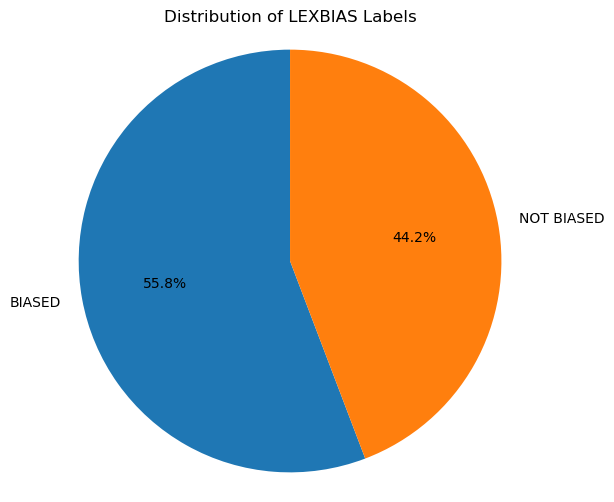


Showing 3 example(s) for label: NOT BIASED
  1: The case was sent back to lower courts to determine whether the gun owners may seek damages or press claims that the amended law still infringes their rights. 
  2: North Carolina’s governor called for the removal of Confederate monuments from State Capitol grounds on Saturday, citing public safety after anti-racism protesters in Raleigh pulled two statues down with ropes Friday night.
  3: Joe Biden's Fourth of July message focused on America's long history of racial injustice -- from slavery to George Floyd's death -- as he called for Americans to strive to achieve the country's founding ideal of equality.

Showing 3 example(s) for label: BIASED
  1: Sen. Dianne Feinstein of California was among the Democratic senators who questioned Barrett earlier this week, and she zeroed in on Trump's egregious behavior. 
  2: Monday for his show’s opening monologue, Fox News Channel’s Tucker Carlson gave a scathing criticism of the Black Lives Mat

In [7]:
plot_distribution(df, label_column="label_text", class_name="LEXBIAS")
show_examples(df, label_column="label_text")

In [8]:
df_train = df[df.split=="train"]
df_train = df_train.drop("split", axis=1)
df_test = df[df.split=="test"]
df_test = df_test.drop("split", axis=1)


In [ ]:
# Split Train in 90%Train and 10% Validation
ds_train_true = Dataset.from_pandas(df_train[df_train.label_text == "BIASED"],preserve_index=False).shuffle(seed=42)
ds_train_false = Dataset.from_pandas(df_train[df_train.label_text == "NOT BIASED"],preserve_index=False).shuffle(seed=42)

dd_true = ds_train_true.train_test_split(test_size=0.1, seed=42)
dd_false = ds_train_false.train_test_split(test_size=0.1, seed=42)


# Combine
dd_final = DatasetDict({"train": concatenate_datasets([dd_true["train"], dd_false["train"]]).shuffle(seed=42),
             "validation": concatenate_datasets([dd_true["test"], dd_false["test"]]).shuffle(seed=42),
             "test": Dataset.from_pandas(df_test, preserve_index=False).shuffle(seed=42)
            })
dd_final


DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'biased_words', 'text_id', 'type', 'label_opinion', 'label_text'],
        num_rows: 2808
    })
    validation: Dataset({
        features: ['text', 'label', 'biased_words', 'text_id', 'type', 'label_opinion', 'label_text'],
        num_rows: 313
    })
    test: Dataset({
        features: ['text', 'label', 'biased_words', 'text_id', 'type', 'label_opinion', 'label_text'],
        num_rows: 1000
    })
})

In [12]:
# Inspect distributions

# Inspect distributions
for k, v in dd_final.items():
    print(f"=== {k} ===")
    counts = Counter(v["label_text"])
    total = sum(counts.values())
    
    for label, count in counts.items():
        percent = (count / total) * 100
        print(f"{label}: {count} ({percent:.2f}%)")
    
    print()


=== train ===
BIASED: 1566 (55.77%)
NOT BIASED: 1242 (44.23%)

=== validation ===
BIASED: 174 (55.59%)
NOT BIASED: 139 (44.41%)

=== test ===
NOT BIASED: 441 (44.10%)
BIASED: 559 (55.90%)



### Upload to HF

In [11]:
dd_final.push_to_hub("TomData/BABE", private=True)

Creating parquet from Arrow format: 100%|██████████| 3/3 [00:00<00:00,  8.31ba/s]
Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 14.75ba/s]
Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00,  6.11ba/s]
Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.
Uploading the dataset shards: 100%|██████████| 1/1 [00:00<00:00,  1.06it/s]
c:\Users\tomkl\.conda\envs\ds_process\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\tomkl\.cache\huggingface\hub\datasets--TomData--BABE. Caching files will still work but in a degraded version that might requi

CommitInfo(commit_url='https://huggingface.co/datasets/TomData/BABE/commit/d3e265e97c9f345819e8334d48a8c796b45271c9', commit_message='Upload dataset', commit_description='', oid='d3e265e97c9f345819e8334d48a8c796b45271c9', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/TomData/BABE', endpoint='https://huggingface.co', repo_type='dataset', repo_id='TomData/BABE'), pr_revision=None, pr_num=None)